# Sample 2 — Embeddings, by hand

`sample-1` turned text into integer ids. Ids are just labels though — `3` isn't "closer" to `4`
than it is to `9` in any meaningful sense. This notebook turns each id into a **vector**, and adds
information about *where* each token sits in the sequence, so what comes out is exactly the input
a transformer's attention layer expects.

**Goals**
1. Build a tiny embedding lookup table by hand (`d_model = 4`) and look up token vectors.
2. Compute sinusoidal positional encoding directly from its formula.
3. Add the two together to get the final input matrix `X`.


## 1. Tokens, again

A 4-word sentence, tokenized the same way as `sample-1` (word-level, tiny vocabulary).

In [1]:
import numpy as np

sentence = "the cat sat mat"
words = sentence.split()

vocab = sorted(set(words))
token_to_id = {tok: i for i, tok in enumerate(vocab)}
ids = [token_to_id[w] for w in words]

print("vocab:", token_to_id)
print("ids:  ", ids)


vocab: {'cat': 0, 'mat': 1, 'sat': 2, 'the': 3}
ids:   [3, 0, 2, 1]


## 2. Embedding lookup table

An embedding table is just a matrix of shape `(vocab_size, d_model)` — one row per vocabulary
token. "Looking up" the embedding for a token id is nothing more than **indexing into that row**.

We use `d_model = 4` (real models use hundreds or thousands) so every vector fits on screen, and
seed the random generator so the numbers are the same every time this notebook runs — exactly
like a freshly *initialized*, not-yet-trained model would look.

In [2]:
rng = np.random.default_rng(seed=0)

vocab_size = len(vocab)
d_model = 4

embedding_table = rng.normal(loc=0.0, scale=0.5, size=(vocab_size, d_model)).round(3)
print("embedding_table shape:", embedding_table.shape)
embedding_table


embedding_table shape: (4, 4)


array([[ 0.063, -0.066,  0.32 ,  0.052],
       [-0.268,  0.181,  0.652,  0.474],
       [-0.352, -0.633, -0.312,  0.021],
       [-1.163, -0.109, -0.623, -0.366]])

In [3]:
# "Looking up" an embedding is just indexing a row of the table
token_embeddings = embedding_table[ids]
print("token_embeddings shape:", token_embeddings.shape)
for word, i, vec in zip(words, ids, token_embeddings):
    print(f"  {word!r:6} (id {i}) -> {vec}")


token_embeddings shape: (4, 4)
  'the'  (id 3) -> [-1.163 -0.109 -0.623 -0.366]
  'cat'  (id 0) -> [ 0.063 -0.066  0.32   0.052]
  'sat'  (id 2) -> [-0.352 -0.633 -0.312  0.021]
  'mat'  (id 1) -> [-0.268  0.181  0.652  0.474]


## 3. Positional encoding

Attention (next notebook) treats the input as a *set* of vectors — on its own it has no notion of
order. "cat sat" and "sat cat" would look identical to it. Positional encoding fixes this by
adding a pattern that depends on each token's position in the sequence.

The original Transformer paper's formula, for position `pos` and embedding dimension index `i`:

```
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

Even dimensions get `sin`, odd dimensions get `cos`, and the "wavelength" grows with the
dimension index — so nearby positions produce similar-but-distinguishable patterns.

In [4]:
def positional_encoding(seq_len, d_model):
    pe = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            angle = pos / (10000 ** (i / d_model))
            pe[pos, i] = np.sin(angle)
            if i + 1 < d_model:
                pe[pos, i + 1] = np.cos(angle)
    return pe

seq_len = len(words)
pos_encoding = positional_encoding(seq_len, d_model).round(3)
print("positional encoding shape:", pos_encoding.shape)
pos_encoding


positional encoding shape: (4, 4)


array([[ 0.   ,  1.   ,  0.   ,  1.   ],
       [ 0.841,  0.54 ,  0.01 ,  1.   ],
       [ 0.909, -0.416,  0.02 ,  1.   ],
       [ 0.141, -0.99 ,  0.03 ,  1.   ]])

Each row is a fixed pattern for that position — computed from a formula, not learned. Row 0
(`pos=0`) is always `[0, 1, 0, 1, ...]` since `sin(0)=0` and `cos(0)=1`; later rows drift away
from that as `pos` grows.

To see the wave pattern properly we need more than 4 dimensions and 4 positions — let's compute a
bigger version purely for visualization.

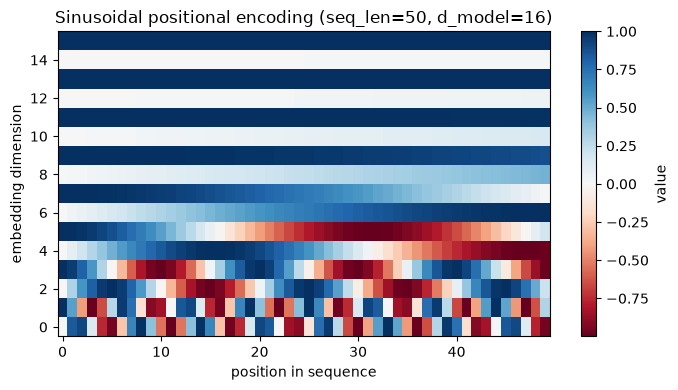

In [5]:
import matplotlib.pyplot as plt

big_pe = positional_encoding(seq_len=50, d_model=16)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(big_pe.T, aspect="auto", cmap="RdBu", origin="lower")
ax.set_xlabel("position in sequence")
ax.set_ylabel("embedding dimension")
ax.set_title("Sinusoidal positional encoding (seq_len=50, d_model=16)")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()


Lower dimensions (bottom rows) oscillate fast — they distinguish neighboring positions.
Higher dimensions (top rows) oscillate slowly — they distinguish positions that are far apart.
Together, every position ends up with a unique combined pattern.

## 4. Token embedding + positional encoding = input to attention

The standard recipe is simply element-wise addition: same shape, added together.

In [6]:
X = token_embeddings + pos_encoding
print("X shape:", X.shape, " (seq_len, d_model)")
X


X shape: (4, 4)  (seq_len, d_model)


array([[-1.163,  0.891, -0.623,  0.634],
       [ 0.904,  0.474,  0.33 ,  1.052],
       [ 0.557, -1.049, -0.292,  1.021],
       [-0.127, -0.809,  0.682,  1.474]])

`X` is what a transformer's first attention layer actually sees: for each token, a vector that
encodes *both* "which word is this" (from the embedding table) and "where in the sequence is it"
(from the positional encoding).

**Next:** `sample-3-attention-by-hand` takes this exact `X` matrix and computes scaled
dot-product attention over it, one matrix multiplication at a time.